In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df = pd.read_csv("C:\All project\Smart Phone web scraping\Smart_Phone_data_cleaned.csv")


# Set a clean style for the charts
sns.set_theme(style="whitegrid")

# Display the first few rows(testing the data)
df.head()

,Company_Name,Model_Name,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery_Capacity,Screen_Size,Price_Pakistan,Price_India,Price_China,Price_USA,Price_Dubai,Launched_Year
0,Apple,iPhone 16 128GB,174.0,6.0,12,48,A17 Bionic,3600.0,6.1,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12,48,A17 Bionic,3600.0,6.1,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12,48,A17 Bionic,3600.0,6.1,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12,48,A17 Bionic,4200.0,6.7,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12,48,A17 Bionic,4200.0,6.7,259999.0,94999.0,6499.0,949.0,3399.0,2024


## 1. Number of Smart Phone by Brand

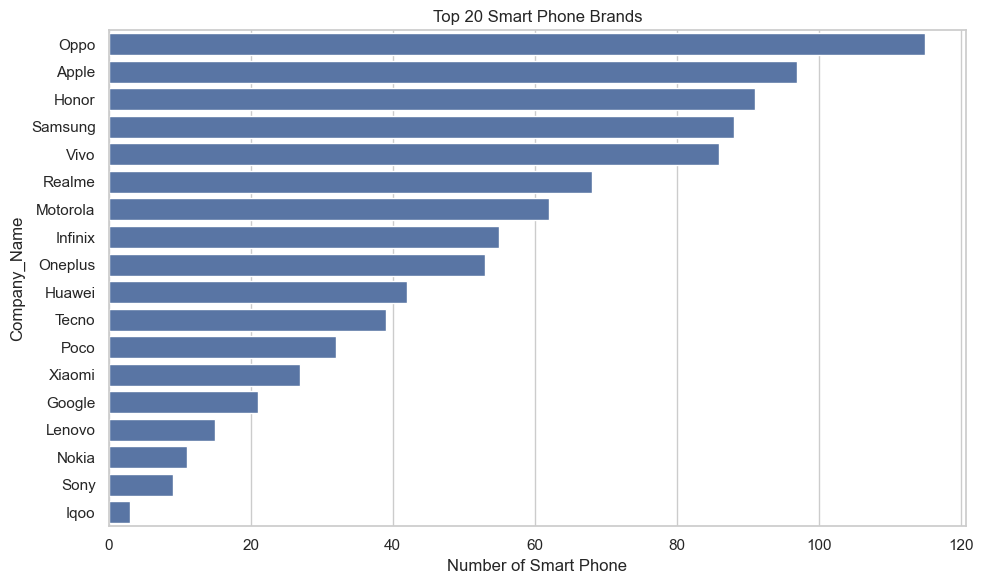

In [3]:
brand_counts = df["Company_Name"].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=brand_counts.values, y=brand_counts.index)
plt.title("Top 20 Smart Phone Brands")
plt.xlabel("Number of Smart Phone")
plt.ylabel("Company_Name")
plt.tight_layout()
plt.show()

## 2. Average Smart Phone Price by Brand


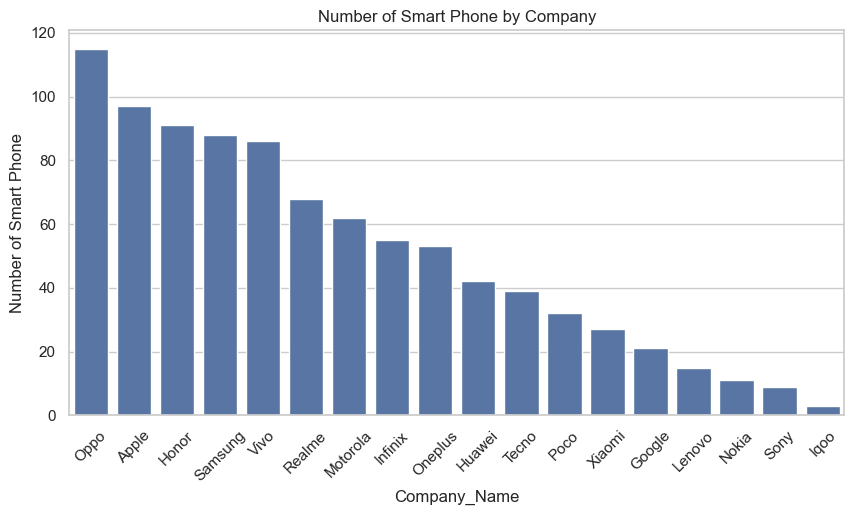

In [4]:
# Calculate average price for each brand and select the top 10
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Company_Name",
    order=df["Company_Name"].value_counts().index
)
plt.title("Number of Smart Phone by Company")
plt.xlabel("Company_Name")
plt.ylabel("Number of Smart Phone")

plt.xticks(rotation=45)
plt.show()

## 3. RAM Distribution

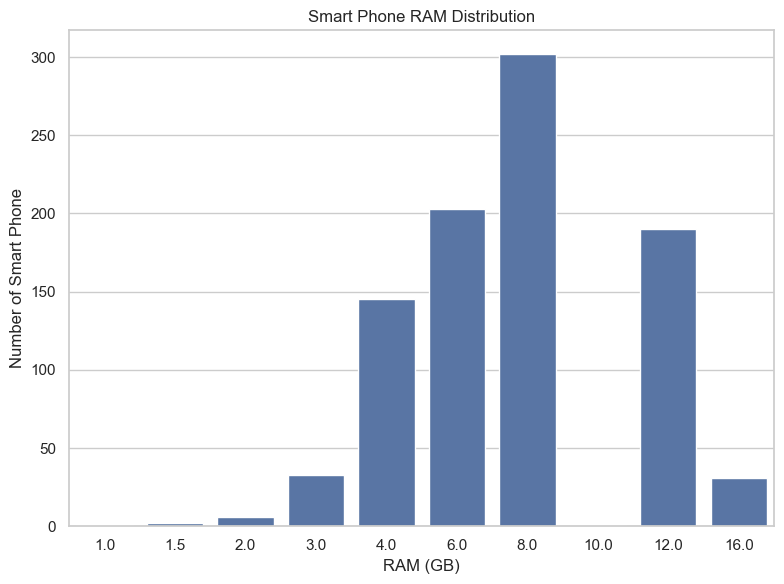

In [5]:
# Count laptops for each RAM value
ram_counts = df["RAM"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=ram_counts.index, y=ram_counts.values)
plt.title("Smart Phone RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smart Phone")
plt.tight_layout()
plt.show()

## 4.Battary Distribution

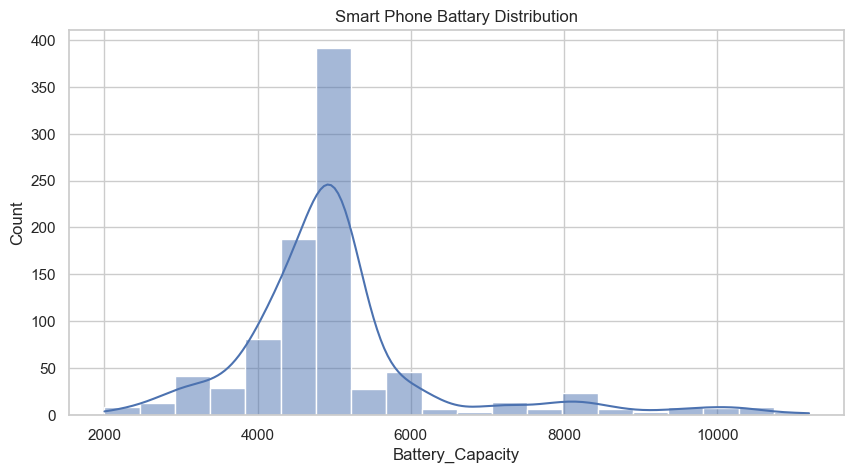

In [6]:
# Show the distribution of laptop ratings
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Battery_Capacity",
    bins=20,
    kde=True
)
plt.title("Smart Phone Battary Distribution")
plt.xlabel("Battery_Capacity")
plt.ylabel("Count")
plt.show()

# 5.Battary boxplots

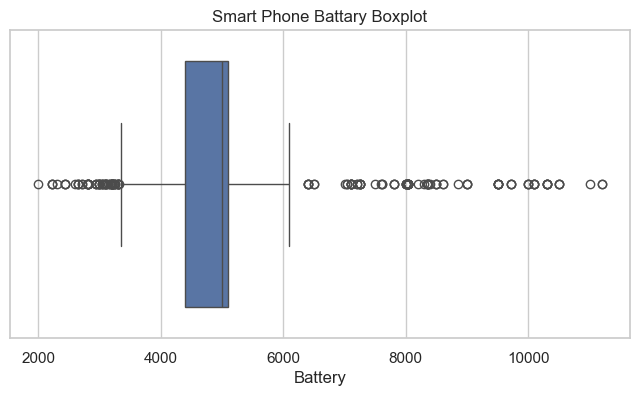

In [7]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Battery_Capacity"]
)
plt.title("Smart Phone Battary Boxplot")
plt.xlabel("Battery")
plt.show()

## 6. RAM affect by Price



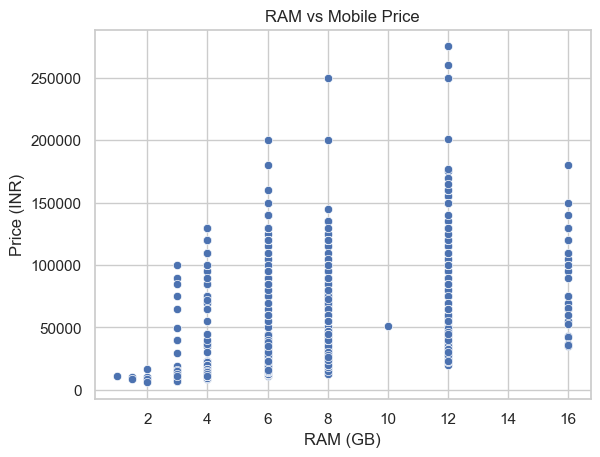

In [8]:
sns.scatterplot(data=df, x="RAM", y="Price_India")

plt.title("RAM vs Mobile Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.show()

## 7.Launches per year by Smart Phone 

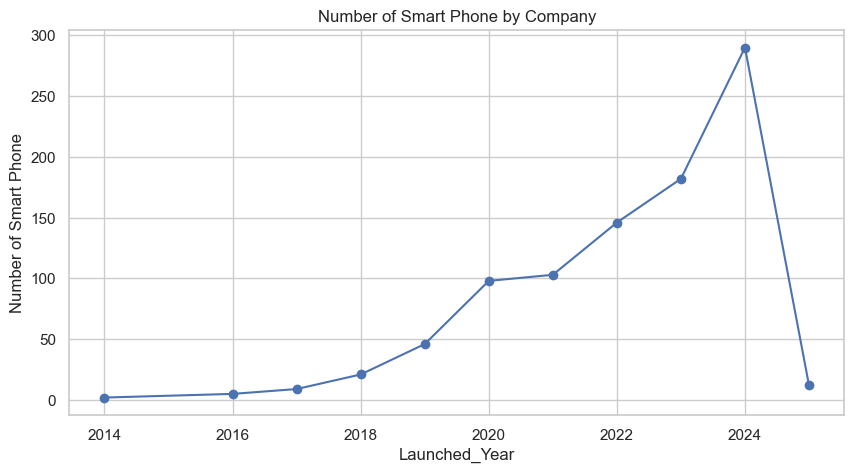

In [10]:
plt.figure(figsize=(10, 5))

Year_count = df["Launched_Year"].value_counts().sort_index()
plt.plot(Year_count.index, Year_count.values, marker='o')
    
plt.title("Number of Smart Phone by Company")
plt.xlabel("Launched_Year")
plt.ylabel("Number of Smart Phone")

plt.xticks(rotation=0)
plt.show()

## 8.Mobile Weight Distribution

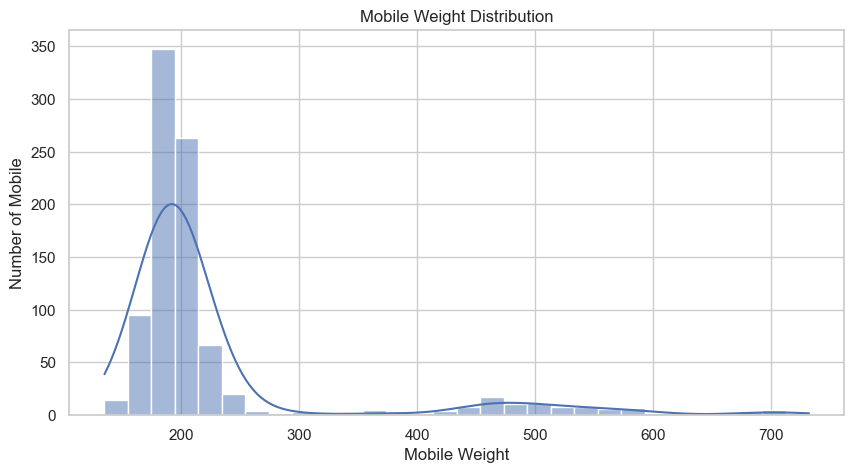

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df["Mobile_Weight"].dropna(),
    bins=30,
    kde=True
    
)

plt.title("Mobile Weight Distribution")
plt.xlabel("Mobile Weight")
plt.ylabel("Number of Mobile")

plt.xticks(rotation=0)

plt.show()

## 9.Megapixel Affect Price

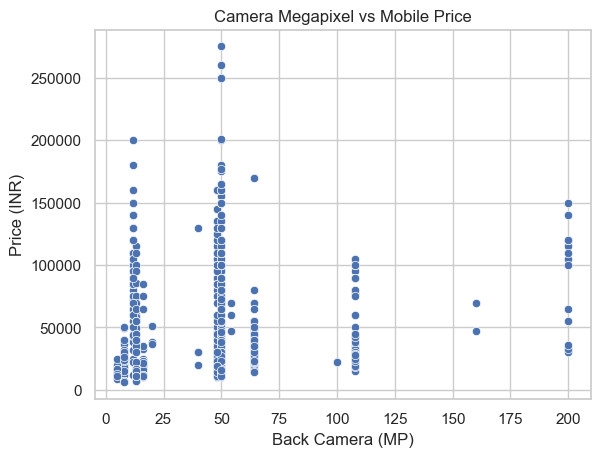

In [11]:
sns.scatterplot(data = df, x = "Back_Camera", y="Price_India")

plt.title("Camera Megapixel vs Mobile Price")
plt.xlabel("Back Camera (MP)")
plt.ylabel("Price (INR)")
plt.show()

## 10.Count Smart Mobile for each RAM value

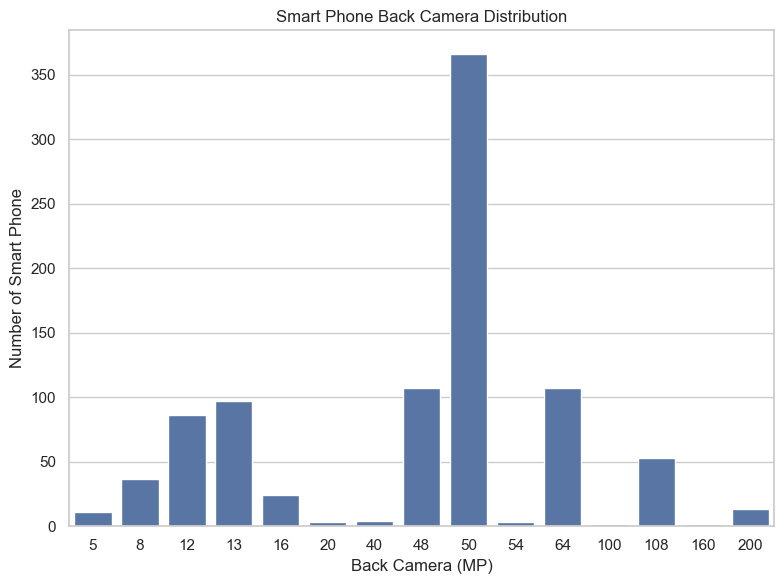

In [ ]:
# Count Smart Mobile for each RAM value
ram_counts = df["Back_Camera"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=ram_counts.index, y=ram_counts.values)
plt.title("Smart Phone Back Camera Distribution")
plt.xlabel("Back Camera (MP)")
plt.ylabel("Number of Smart Phone")
plt.tight_layout()
plt.show()

## 11.Average Price by Brand

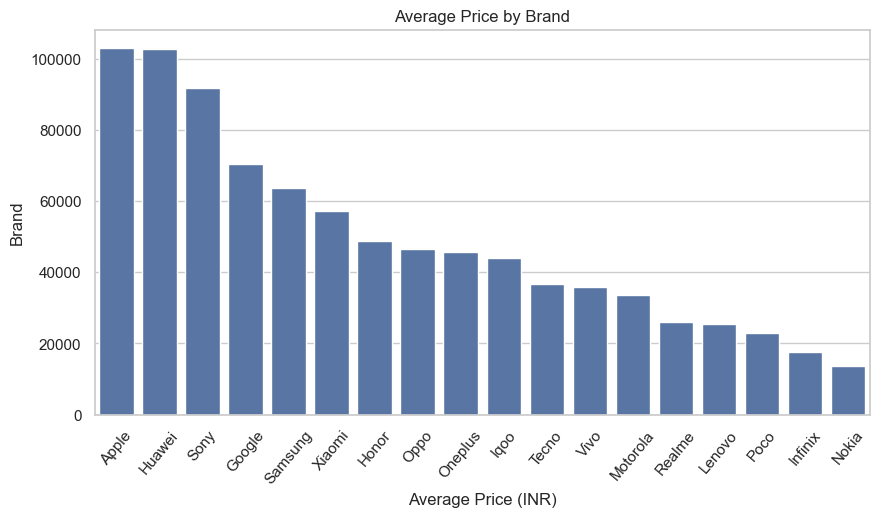

In [20]:
plt.figure(figsize=(10, 5))

Brand_Price = (df.groupby("Company_Name")["Price_India"].mean().sort_values(ascending=False))

sns.barplot(x=Brand_Price.index, y=Brand_Price.values)
plt.title("Average Price by Brand")
plt.xlabel("Average Price (INR)")
plt.ylabel("Brand")
plt.xticks(rotation=50)
plt.show()

## 12.Premium Phone

In [35]:
# create Premium Phone

Premium_limit = df["Price_India"].quantile(0.75)  # Define premium limit as the 75th percentile of prices
Premium = df[df["Price_India"] > Premium_limit]



### 1.RAM distribution of Premium phone

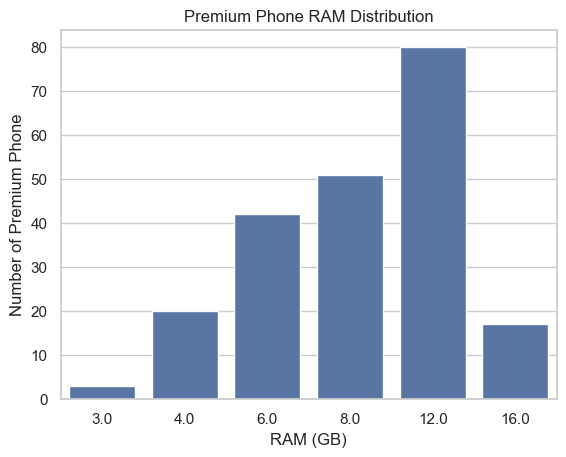

In [27]:
sns.countplot(data =Premium,x="RAM")
plt.title("Premium Phone RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Premium Phone")
plt.show()

### 2.Back Camera Distribution of Premium Phone

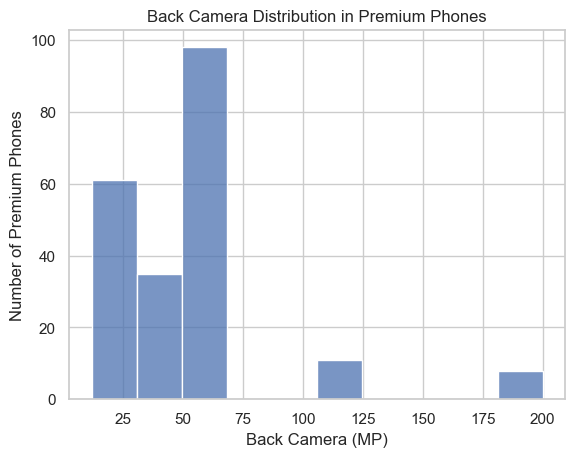

In [29]:
sns.histplot(data = Premium, x="Back_Camera", bins=10)

plt.title("Back Camera Distribution in Premium Phones")
plt.xlabel("Back Camera (MP)")
plt.ylabel("Number of Premium Phones")
plt.show()


### 3.Battery Capacity Distribution of Premium Phone

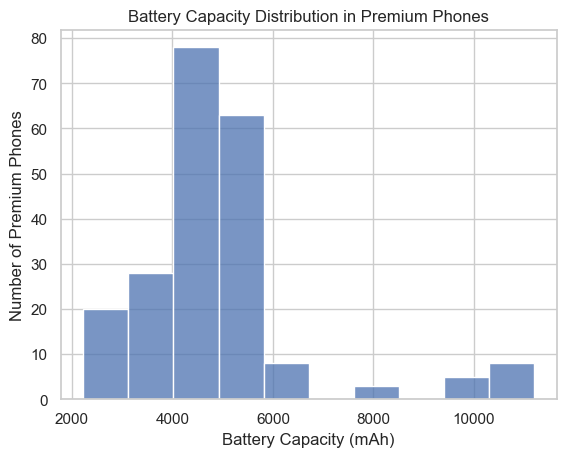

In [31]:
sns.histplot(data = Premium, x="Battery_Capacity", bins=10)

plt.title("Battery Capacity Distribution in Premium Phones")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Number of Premium Phones")
plt.show()


### final

In [34]:
print("Common RAM:")
print(Premium["RAM"].mode()[0])  # Display the most common RAM value in premium phones

print("Common Back Camera:")
print(Premium["Back_Camera"].mode()[0])  # Display the most common Back Camera value in premium phones

print("Common Battery Capacity:")
print(Premium["Battery_Capacity"].mode()[0])  # Display the most common Battery Capacity value in premium phones

Common RAM:
12.0
Common Back Camera:
50
Common Battery Capacity:
5000.0
